In [1]:
# Cell 1 - Imports
import os
import numpy as np
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
tqdm.pandas()

pd.set_option("display.max_colwidth", 80)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

In [2]:
# CELL 2 — Load & inspect HaluEval summarization subset
raw = pd.DataFrame(
    load_dataset("pminervini/HaluEval", "summarization_samples", split="data")
)
print("Columns:", raw.columns.tolist())
print("Shape:", raw.shape)
print("\nSample row:")
raw.head(2)

summarization_samples/data-00000-of-0000(…):   0%|          | 0.00/25.5M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Columns: ['document', 'summary', 'hallucination']
Shape: (10000, 3)

Sample row:


,document,summary,hallucination
0,"Marseille, France (CNN)The French prosecutor leading an investigation into t...",A video showing the final moments of Germanwings Flight 9525 has been recove...,yes
1,The Palestinian Authority officially became the 123rd member of the Internat...,Membership gives the ICC jurisdiction over alleged crimes committed in Pales...,no


In [7]:
# CELL 3 — Understanding the structure
print("Summary length (words):")
print(raw["summary"].str.split().str.len().describe())

print("\nHallucination label distribution:")
print(raw["hallucination"].value_counts())

print("\nSample correct summary (hallucination=no):")
print(raw[raw["hallucination"]=="no"]["summary"].iloc[0])
print("\nSample hallucinated summary (hallucination=yes):")
print(raw[raw["hallucination"]=="yes"]["summary"].iloc[0])

Summary length (words):
count    10000.000000
mean        60.748900
std         26.093009
min          8.000000
25%         42.000000
50%         55.000000
75%         77.000000
max        497.000000
Name: summary, dtype: float64

Hallucination label distribution:
hallucination
yes    5010
no     4990
Name: count, dtype: int64

Sample correct summary (hallucination=no):
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June. Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis.


Sample hallucinated summary (hallucination=yes):
A video showing the final moments of Germanwings Flight 9525 has been recovered by investigators from the wreckage site. Marseille prosecutor Brice Robin urged anyone who might have more footage to turn it over immediately. Andreas Lubitz, the co-pilot accused of deliberately crashing the plane, had a history of severe depression and suicidal

In [8]:
# CELL 4 — Reshape into binary classification format
halueval_sum = raw.copy()
halueval_sum["label"] = (halueval_sum["hallucination"] == "yes").astype(int)
halueval_sum = halueval_sum[["document", "summary", "label"]].reset_index(drop=True)

print("Shape:", halueval_sum.shape)
print("\nLabel distribution:")
print(halueval_sum["label"].value_counts())
print("\nLength by label:")
halueval_sum["summary_len"] = halueval_sum["summary"].str.split().str.len()
print(halueval_sum.groupby("label")["summary_len"].describe())

Shape: (10000, 3)

Label distribution:
label
1    5010
0    4990
Name: count, dtype: int64

Length by label:
        count       mean        std   min   25%   50%   75%    max
label                                                             
0      4990.0  50.611423  21.381564   8.0  36.0  47.0  58.0  497.0
1      5010.0  70.845908  26.446423  11.0  52.0  70.0  88.0  229.0


In [9]:
# CELL 5 — Sample 5000 rows (2500 per class, stratified)
halueval_sample = (
    halueval_sum
    .groupby("label", group_keys=False)
    .apply(lambda x: x.sample(n=2500, random_state=42))
    .reset_index(drop=True)
)

print("Sampled shape:", halueval_sample.shape)
print("\nLabel distribution after sampling:")
print(halueval_sample["label"].value_counts())

Sampled shape: (5000, 4)

Label distribution after sampling:
label
0    2500
1    2500
Name: count, dtype: int64


C:\Users\intel\AppData\Local\Temp\ipykernel_17944\690458557.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=2500, random_state=42))


In [10]:
# CELL 6 — Feature 1: Response length
# Verify no length bias — both classes should be similar
halueval_sample["response_len"] = (
    halueval_sample["summary"].fillna("").str.split().str.len()
)
print("Response length by label:")
print(halueval_sample.groupby("label")["response_len"].describe())

Response length by label:
        count     mean        std   min   25%   50%   75%    max
label                                                           
0      2500.0  50.2972  21.225576  12.0  36.0  47.0  58.0  497.0
1      2500.0  70.4452  26.009552  11.0  51.0  70.0  88.0  188.0


In [11]:
# CELL 7 — Feature 2: Hedge count
HEDGE_WORDS = [
    "might", "may", "could", "possibly", "perhaps", "probably", "i think",
    "i believe", "i'm not sure", "unclear", "uncertain", "debated",
    "some say", "allegedly", "supposedly", "it seems", "appears to"
]

def count_hedges(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return sum(1 for h in HEDGE_WORDS if h in text.lower())

halueval_sample["hedge_count"] = halueval_sample["summary"].apply(count_hedges)
print("Hedge count by label:")
print(halueval_sample.groupby("label")["hedge_count"].describe())

Hedge count by label:
        count    mean       std  min  25%  50%  75%  max
label                                                   
0      2500.0  0.1520  0.376501  0.0  0.0  0.0  0.0  2.0
1      2500.0  0.1664  0.407403  0.0  0.0  0.0  0.0  3.0


In [12]:
# CELL 8 — Feature 3: ROUGE-1, ROUGE-L, BLEU
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
smoother = SmoothingFunction().method1

def compute_rouge_bleu(response: str, reference: str) -> dict:
    if not isinstance(response, str) or not isinstance(reference, str):
        return {"rouge1": 0.0, "rougeL": 0.0, "bleu": 0.0}
    scores = scorer.score(reference, response)
    ref_tok = reference.lower().split()
    hyp_tok = response.lower().split()
    bleu = sentence_bleu([ref_tok], hyp_tok, smoothing_function=smoother)
    return {
        "rouge1": scores["rouge1"].fmeasure,
        "rougeL": scores["rougeL"].fmeasure,
        "bleu" : bleu
    }

print("Computing ROUGE/BLEU...")
rb = halueval_sample.progress_apply(
    lambda r: compute_rouge_bleu(r["summary"], r["document"]), axis=1
)
halueval_sample["rouge1"] = rb.apply(lambda x: x["rouge1"])
halueval_sample["rougeL"] = rb.apply(lambda x: x["rougeL"])
halueval_sample["bleu"] = rb.apply(lambda x: x["bleu"])
print("Done.")
print("\nROUGE-1 mean by label:")
print(halueval_sample.groupby("label")["rouge1"].mean())


Computing ROUGE/BLEU...


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [01:41<00:00, 49.20it/s]

Done.

ROUGE-1 mean by label:
label
0    0.152422
1    0.183049
Name: rouge1, dtype: float64


In [13]:
# CELL 9 — Feature 4: Semantic similarity
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Loading sentence-transformers model...")
st_model = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = st_model.encode(
    halueval_sample["document"].fillna("").tolist(),
    batch_size=64, show_progress_bar=True
)
sum_embeddings = st_model.encode(
    halueval_sample["summary"].fillna("").tolist(),
    batch_size=64, show_progress_bar=True
)
halueval_sample["sem_sim"] = cosine_similarity(
    sum_embeddings, doc_embeddings
).diagonal()

print("\nSemantic similarity mean by label:")
print(halueval_sample.groupby("label")["sem_sim"].mean())

# Autosave
halueval_sample.to_csv("../data/processed/halueval_sum_features.csv", index=False)
print("saved after semantic similarity.")

Loading sentence-transformers model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]


Semantic similarity mean by label:
label
0    0.749355
1    0.759377
Name: sem_sim, dtype: float32
saved after semantic similarity.


In [14]:
# CELL 10 — Feature 5: BERTScore
from bert_score import score as bert_score

print("Computing BERTScore")
cands = halueval_sample["summary"].fillna("").tolist()
refs  = halueval_sample["document"].fillna("").tolist()

P, R, F1 = bert_score(
    cands, refs,
    lang="en",
    model_type="distilbert-base-uncased",
    batch_size=32,
    verbose=True
)
halueval_sample["bertscore_f1"] = F1.numpy()
print("\nBERTScore F1 mean by label:")
print(halueval_sample.groupby("label")["bertscore_f1"].mean())

# Autosave
halueval_sample.to_csv("../data/processed/halueval_sum_features.csv", index=False)
print("saved after BERTScore.")

Computing BERTScore


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


calculating scores...
computing bert embedding.


  0%|          | 0/313 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/157 [00:00<?, ?it/s]

done in 1926.62 seconds, 2.60 sentences/sec

BERTScore F1 mean by label:
label
0    0.783278
1    0.779036
Name: bertscore_f1, dtype: float32
saved after BERTScore.


In [15]:
# CELL 11 — Feature 6: NLI entailment score
# Premise = document, Hypothesis = summary
from transformers import pipeline

print("Loading NLI model")
nli_pipe = pipeline(
    "text-classification",
    model="cross-encoder/nli-deberta-v3-small",
    device=-1
)

def get_nli_entailment(premise: str, hypothesis: str) -> float:
    if not isinstance(premise, str) or not isinstance(hypothesis, str):
        return 0.0
    try:
        result = nli_pipe(
            f"{premise[:400]} [SEP] {hypothesis[:400]}",
            truncation=True,
            max_length=512
        )
        label = result[0]["label"].lower()
        score = result[0]["score"]
        if label == "entailment":
            return score
        elif label == "contradiction":
            return -score
        else:
            return 0.0
    except Exception:
        return 0.0

print("Computing NLI scores")
halueval_sample["nli_score"] = halueval_sample.progress_apply(
    lambda r: get_nli_entailment(r["document"], r["summary"]), axis=1
)
print("\nNLI score mean by label:")
print(halueval_sample.groupby("label")["nli_score"].mean())

# Autosave
halueval_sample.to_csv("../data/processed/halueval_sum_features.csv", index=False)
print("saved after NLI.")

Loading NLI model


Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing NLI scores


100%|██████████████████████████████████████████████████████████████████████████████| 5000/5000 [22:07<00:00,  3.77it/s]



NLI score mean by label:
label
0    0.009676
1   -0.038691
Name: nli_score, dtype: float64
saved after NLI.


In [16]:
# CELL 12 — Verify feature matrix
FEATURE_COLS = [
    "response_len", "hedge_count", "rouge1", "rougeL",
    "bleu", "sem_sim", "bertscore_f1", "nli_score"
]

print(f"Shape: {halueval_sample.shape}")
print(f"\nNull counts:\n{halueval_sample[FEATURE_COLS].isnull().sum()}")
print(f"\nMean by label:")
print(halueval_sample.groupby("label")[FEATURE_COLS].mean().round(4))

Shape: (5000, 12)

Null counts:
response_len    0
hedge_count     0
rouge1          0
rougeL          0
bleu            0
sem_sim         0
bertscore_f1    0
nli_score       0
dtype: int64

Mean by label:
       response_len  hedge_count  rouge1  rougeL    bleu  sem_sim  \
label                                                               
0           50.2972       0.1520  0.1524  0.1107  0.0017   0.7494   
1           70.4452       0.1664  0.1830  0.1194  0.0026   0.7594   

       bertscore_f1  nli_score  
label                           
0            0.7833     0.0097  
1            0.7790    -0.0387  


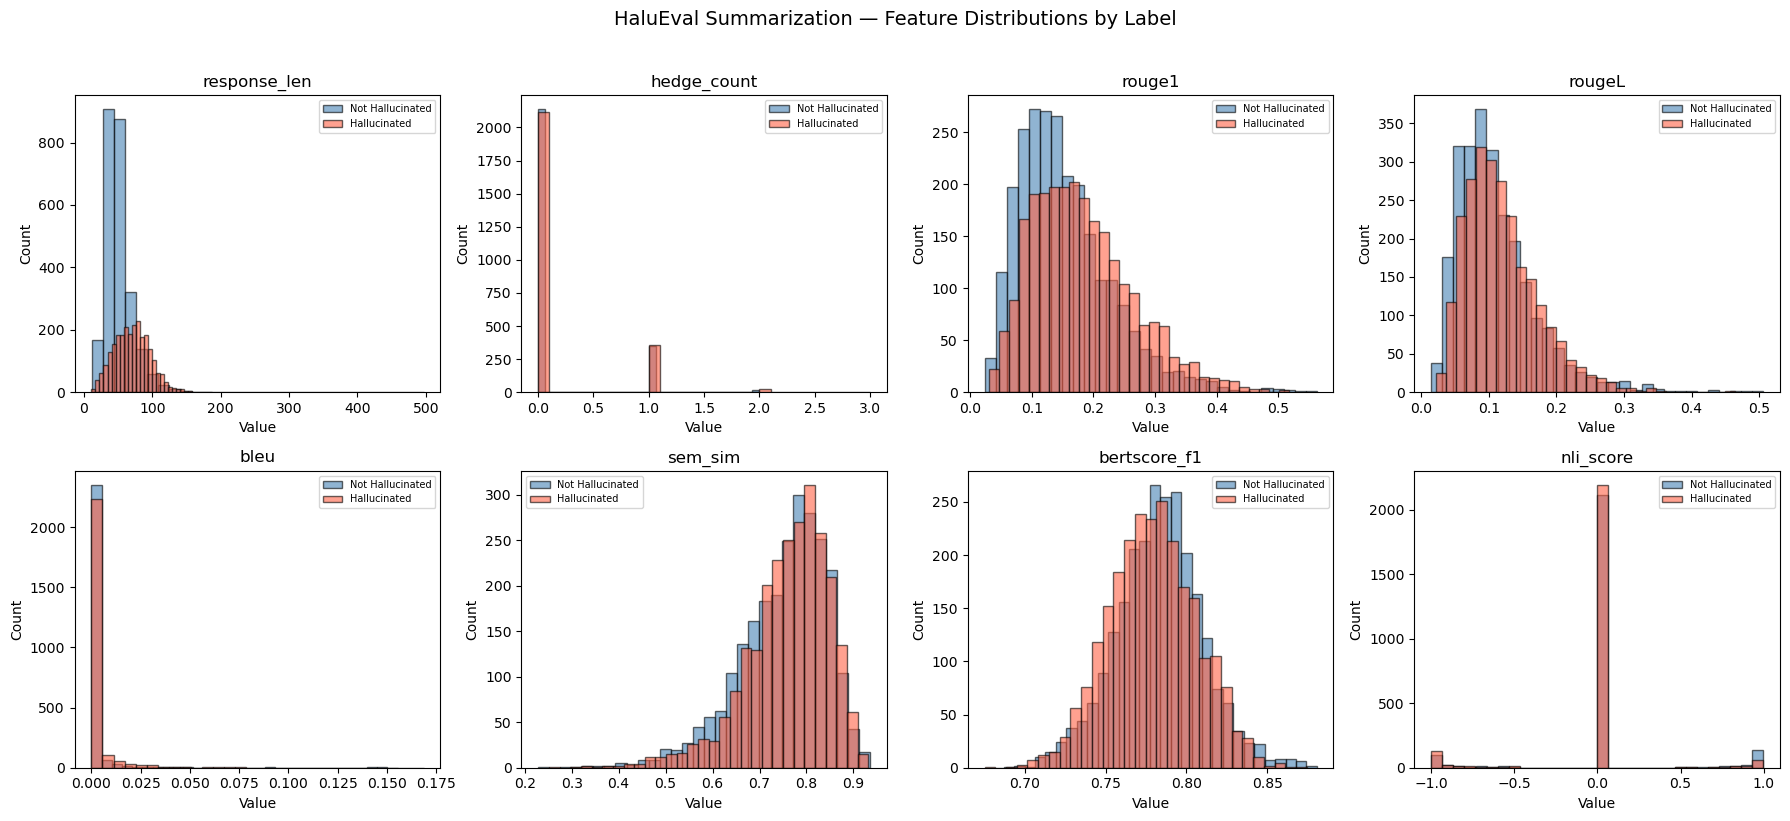

In [17]:
# CELL 13 — EDA: Feature distributions by label
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(FEATURE_COLS):
    for label, grp in halueval_sample.groupby("label"):
        axes[i].hist(
            grp[feat], bins=30, alpha=0.6,
            label="Not Hallucinated" if label == 0 else "Hallucinated",
            color="steelblue" if label == 0 else "tomato",
            edgecolor="black"
        )
    axes[i].set_title(feat)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].legend(fontsize=7)

plt.suptitle("HaluEval Summarization — Feature Distributions by Label",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/halueval_sum_feature_distributions.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# CELL 14 — Save final feature matrix
halueval_sample.to_csv("../data/processed/halueval_sum_features.csv", index=False)
print("Saved halueval_sum_features.csv —", halueval_sample.shape)

Saved halueval_sum_features.csv — (5000, 12)
